PROJECT OBJECTIVE: Build a sequential NLP classifier which can use input text parameters to determine the customer sentiments.

1. Read and explore the data
2. Retain relevant columns
3. Get length of each sentence
4. Define parameters
5. Get indices for words
6. Create features and labels
7. Get vocabulary size
8. Create a weight matrix using GloVe embeddings
9. Define and compile a Bidirectional LSTM model.
 Hint: Be analytical and experimental here in trying new approaches to design the best model.
10. Fit the model and check the validation accuracy

In [ ]:
import sys
sys.version

'3.7.12 (default, Sep 10 2021, 00:21:48) \n[GCC 7.5.0]'

In [ ]:
#!pip install -U pandas

In [1]:
#Import libraries
import pandas as pd
import numpy as np

#Viz libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# general processing libs
import random
import re
import os
import string
from string import punctuation

#Warning filter
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation, Flatten, Bidirectional, GlobalMaxPool1D, TimeDistributed
from tensorflow.keras.models import Sequential
from keras import optimizers
from keras.models import Model
from keras.utils.vis_utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

#sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

#NLTK libraries
from bs4 import BeautifulSoup
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

pd.options.display.max_colwidth = None

In [4]:
!pip install transformers

     |████████████████████████████████| 2.8 MB 5.2 MB/s 
     |████████████████████████████████| 636 kB 43.9 MB/s 
     |████████████████████████████████| 895 kB 35.8 MB/s 
     |████████████████████████████████| 52 kB 1.4 MB/s 
     |████████████████████████████████| 3.3 MB 34.5 MB/s 
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 3.13
    Uninstalling PyYAML-3.13:
      Successfully uninstalled PyYAML-3.13


In [5]:
import transformers

#BERT Model imports
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, BertTokenizer, TFBertForSequenceClassification
from transformers import TFTrainer, TFTrainingArguments

**Q1: Read and explore the data**

In [6]:
df = pd.read_json("/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/Assessment/Sarcasm_Headlines_Dataset.json", lines=True)
dfv2 = pd.read_json("/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/Assessment/Sarcasm_Headlines_Dataset_v2.json", lines=True)
df=pd.concat([df,dfv2])
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5,former versace store clerk sues over secret 'black code' for minority shoppers,0
1,https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365,"the 'roseanne' revival catches up to our thorny political mood, for better and worse",0
2,https://local.theonion.com/mom-starting-to-fear-son-s-web-series-closest-thing-she-1819576697,mom starting to fear son's web series closest thing she will have to grandchild,1
3,https://politics.theonion.com/boehner-just-wants-wife-to-listen-not-come-up-with-alt-1819574302,"boehner just wants wife to listen, not come up with alternative debt-reduction ideas",1
4,https://www.huffingtonpost.com/entry/jk-rowling-wishes-snape-happy-birthday_us_569117c4e4b0cad15e64fdcb,j.k. rowling wishes snape happy birthday in the most magical way,0


In [7]:
df.shape

(55328, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55328 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_link  55328 non-null  object
 1   headline      55328 non-null  object
 2   is_sarcastic  55328 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [9]:
df.isnull().sum()

article_link    0
headline        0
is_sarcastic    0
dtype: int64

In [ ]:
#df = df.drop_duplicates(keep='first')

In [10]:
df['is_sarcastic'].value_counts()

0    29970
1    25358
Name: is_sarcastic, dtype: int64

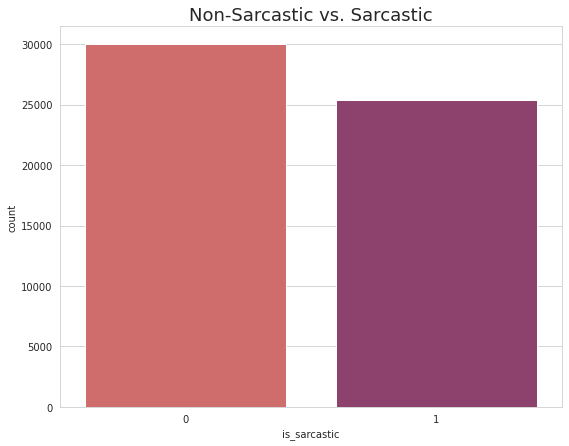

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize = (9,7))

plt.title("Non-Sarcastic vs. Sarcastic", fontsize=18)
sns.countplot(x="is_sarcastic",data=df, palette="flare")

**Q2: Retain relevant columns**

In [11]:
#article_link feature is not required and hence dropped from dataframe.
df.drop(['article_link'], axis=1, inplace=True)

In [ ]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'black code' for minority shoppers,0
1,"the 'roseanne' revival catches up to our thorny political mood, for better and worse",0
2,mom starting to fear son's web series closest thing she will have to grandchild,1
3,"boehner just wants wife to listen, not come up with alternative debt-reduction ideas",1
4,j.k. rowling wishes snape happy birthday in the most magical way,0


**Preprocess data - 'headline' feature**

In [12]:
def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()


##Removing the stopwords from text
stop = set(stopwords.words('english'))
punctuation = list(string.punctuation)
stop.update(punctuation)

def remove_stopwords(text):
    final_text = []
    for i in text.split():
        if i.strip().lower() not in stop:
            final_text.append(i.strip())
    return " ".join(final_text)


# Removing URL's
def remove_between_square_brackets(text):
    return re.sub(r'http\S+', '', text)

In [13]:
def preprocess_data(s):
    # maintain case of the letters and remove extra white spaces 
    s = str(s).lower().strip()
    
    # remove the short forms and spelling misses 
    #s = " ".join([mispell_dict[word] if word in mispell_dict.keys() else word for word in s.split()])
    
    # remove the nextline characters 
    s = re.sub('/n','',s)
    
    # filter the characters 
    s  = re.sub(r"([?!,+=—&%\'\";:¿।।।|\(\).{}\[\]//])",'', s)
    
    # replace multiple spaces with single space 
    s = re.sub(' +', ' ', s)

    s= remove_stopwords(s)

    s= strip_html(s)

    # s= remove_between_square_brackets(s)
    
    return s

In [14]:
df['headline'] = df['headline'].apply(preprocess_data)

In [ ]:
df['headline'].head(10)

0    former versace store clerk sues secret black code minority shoppers
1            roseanne revival catches thorny political mood better worse
2             mom starting fear sons web series closest thing grandchild
3        boehner wants wife listen come alternative debt-reduction ideas
4                     jk rowling wishes snape happy birthday magical way
5                                                 advancing worlds women
6                                 fascinating case eating lab-grown meat
7                                      ceo send kids school work company
8                     top snake handler leaves sinking huckabee campaign
9                       fridays morning email inside trumps presser ages
Name: headline, dtype: object

In [ ]:
df["headline"].iloc[32]

'uber vows repay nyc drivers tens millions tax snafu'

**Q3. Get length of each sentence**

In [15]:
df['len']=df['headline'].apply(lambda x:len(x.split(" ")))

In [ ]:
df.head()

,headline,is_sarcastic,len
0,former versace store clerk sues secret black code minority shoppers,0,10
1,roseanne revival catches thorny political mood better worse,0,8
2,mom starting fear sons web series closest thing grandchild,1,9
3,boehner wants wife listen come alternative debt-reduction ideas,1,8
4,jk rowling wishes snape happy birthday magical way,0,8


In [ ]:
#the max length of a sentence - 106
df.describe()

,is_sarcastic,len
count,55328.0000000,55328.0000000
mean,0.4583213,7.2034051
std,0.4982644,2.3624786
min,0.0000000,1.0000000
25%,0.0000000,6.0000000
50%,0.0000000,7.0000000
75%,1.0000000,9.0000000
max,1.0000000,106.0000000


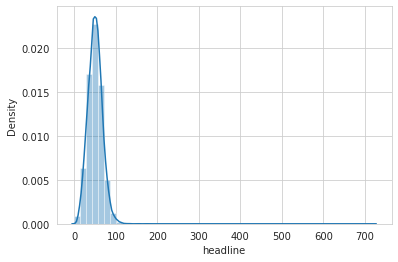

In [ ]:
sns.distplot(df.headline.str.len())

In [16]:
df.sort_values(by='len', ascending=False).head()

,headline,is_sarcastic,len
7302,hot wheels ranked number one toy rolling ramp knocking dominoes send marble funnel dropping onto teeter-totter yanks string causing pulley system raise wooden block propelling series twine rollers unwind spring launching tennis ball across room inching tire slope hits power switch activating table fan blows toy ship nail attached across kiddie pool popping water balloon fills cup weighing lever forces basketball track nudging broomstick axis rotate allowing golf ball roll sideways coffee mug tumbles row hardcover books handle catches hook attached lever causes wooden mallet slam serving spoon catapulting small ball cup attached ribbon lazy susan spins pushes battery incline plane tipping salt shaker season omelet,1,106
2146,maya angelou poet author civil rights activist andholy cowtony award–nominated actress college professor magazine editor streetcar conductorreally streetcar conductor wowcalypso singer nightclub performer foreign journalist dead 86,1,27
19868,maya angelou poet author civil rights activist andholy cowtony award–nominated actress college professor magazine editor streetcar conductorreally streetcar conductor wowcalypso singer nightclub performer foreign journalist dead 86,1,27
15247,elmore leonard modern prose master noted terse prose style writing things perfectly succinctly remarkable economy words unfortunately sadly expired gloomy tuesday age 87 years old,1,25
24815,elmore leonard modern prose master noted terse prose style writing things perfectly succinctly remarkable economy words unfortunately sadly expired gloomy tuesday age 87 years old,1,25


In [17]:
df.sort_values(by='len', ascending=True).head()

,headline,is_sarcastic,len
11228,story,0,1
12465,connected,0,1
1705,interview,0,1
4001,new,0,1
26524,,0,1


In [ ]:
df[df['headline'] == '']

,headline,is_sarcastic,len
5322,,0,1
26524,,0,1


In [18]:
#Remove headline those are empty string - index 5322 and 26524
df=df[df['headline'] != '']
df[df['headline'] == '']

,headline,is_sarcastic,len


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55326 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      55326 non-null  object
 1   is_sarcastic  55326 non-null  int64 
 2   len           55326 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ MB


**Q4: Define parameters**

In [19]:
max_features = 40000
maxlen = 106
embedding_size = 300

***Tokenize the data***

In [20]:
tokenizer=Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['headline'].tolist())

***Create sequences***

In [21]:
X=tokenizer.texts_to_sequences(df['headline']) #map the index value to the text.
print(X)

[[224, 15163, 556, 3374, 2361, 274, 36, 2064, 2655, 8754], [8382, 3460, 2656, 8755, 316, 2845, 161, 943], [70, 679, 746, 1075, 2112, 516, 4746, 133, 11027], [1480, 141, 313, 1588, 231, 2944, 1381, 7235, 809], [4905, 4906, 729, 11028, 483, 475, 1244, 34], [11029, 272, 27], [7236, 254, 356, 3912, 2215, 1382], [325, 1045, 75, 40, 76, 247], [163, 3733, 7237, 476, 5495, 1615, 71], [2113, 248, 267, 317, 18, 15164, 4030], [2945, 1507, 4907, 3, 4031, 7238, 1833, 1024], [189, 734, 348, 1589, 1751, 3734], [155, 431, 3033, 2, 831, 4, 259, 4301, 8756, 69], [146, 4032, 8757, 2765, 11030], [15165, 1328, 537, 581, 233, 866], [466, 1833, 11031, 11032, 2657, 3, 1834], [2580, 1307, 283, 3629, 244, 231, 944, 14509, 1025, 292, 31, 1102], [1403, 8383, 2766, 8384, 7239, 1147], [11033, 760, 1786, 161, 1186, 130, 2846], [3630, 4432, 3034], [8385, 3735, 810, 1383, 11034, 7240], [2, 1245, 55, 661, 667, 5496, 1103, 3461, 2293, 1867, 11035], [4033, 11036, 6231, 10, 3035, 15166, 4908], [1148, 100, 6232], [454, 397

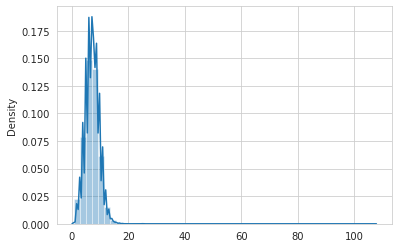

In [ ]:
sns.distplot([len(l) for l in X])

**Q5: Get indices for words**

In [22]:
word_index=len(tokenizer.word_index)
print(word_index)

27346


In [ ]:
len(X)

55326

**Q6. Create features and labels**

In [23]:
X =pad_sequences(X, maxlen=maxlen)
y=np.asarray(df['is_sarcastic'])

In [ ]:
X.shape, y.shape, len(X)

((55326, 106), (55326,), 55326)

In [24]:
#Check the shape of X (padded tokenized headline data) and y (sarcastic) data
print(len(X[0]))
print(len(X[1]))
print(len(y))

106
106
55326


**Q7. Get vocabulary size**

In [25]:
#Check the total number of words in the dictionary (of tekenizer)
vocab_size=len(tokenizer.word_index)+1
vocab_size

27347

**Q8. Create a weight matrix using GloVe embeddings**

In [26]:
EMBEDDING_FILE='/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/Assessment/glove.6B.300d.txt'

embeddings={}
for o in open(EMBEDDING_FILE):
  word=o.split(" ")[0]
  #print(word)
  embd=o.split(" ")[1:]
  embd=np.asarray(embd, dtype='float32')
  #print(embd)
  embeddings[word]=embd

In [ ]:
len(embeddings)

400000

In [27]:
tokenizer.word_index.items()

dict_items([('new', 1), ('trump', 2), ('man', 3), ('us', 4), ('one', 5), ('report', 6), ('year', 7), ('area', 8), ('day', 9), ('woman', 10), ('donald', 11), ('says', 12), ('time', 13), ('first', 14), ('like', 15), ('get', 16), ('old', 17), ('trumps', 18), ('life', 19), ('people', 20), ('house', 21), ('obama', 22), ('white', 23), ('still', 24), ('make', 25), ('back', 26), ('women', 27), ('clinton', 28), ('world', 29), ('could', 30), ('years', 31), ('family', 32), ('americans', 33), ('way', 34), ('5', 35), ('black', 36), ('study', 37), ('american', 38), ('would', 39), ('school', 40), ('gop', 41), ('bill', 42), ('best', 43), ('really', 44), ('show', 45), ('police', 46), ('last', 47), ('watch', 48), ('cant', 49), ('know', 50), ('finds', 51), ('death', 52), ('home', 53), ('good', 54), ('nation', 55), ('president', 56), ('going', 57), ('state', 58), ('3', 59), ('video', 60), ('things', 61), ('big', 62), ('say', 63), ('love', 64), ('health', 65), ('every', 66), ('parents', 67), ('10', 68), ('

In [28]:
embedding_matrix = np.zeros((vocab_size, 300))

for word, i in tokenizer.word_index.items():
  embedding_vector = embeddings.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector 


In [ ]:
embedding_matrix.shape

(27347, 300)

**split the data into training and testing data**

In [29]:
Xtrain, Xtest, ytrain, ytest=train_test_split(X, y, test_size=0.20, random_state=42)
Xtrain.shape, ytrain.shape, Xtest.shape, ytest.shape

((44260, 106), (44260,), (11066, 106), (11066,))

**Q9. Define and compile a Bidirectional LSTM model.  Hint: Be analytical and experimental here in trying new approaches to design the best model.**

In [ ]:
tf.keras.backend.clear_session()
model = Sequential()
#Non-trainable embeddidng layer
model.add(Embedding(vocab_size, output_dim=embedding_size, weights=[embedding_matrix], input_length=maxlen))
#LSTM 
model.add(Bidirectional(LSTM(units=128, return_sequences=True)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=tf.keras.optimizers.Adam(lr = 1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 106, 300)          8204100   
_________________________________________________________________
bidirectional (Bidirectional (None, 106, 256)          439296    
_________________________________________________________________
flatten (Flatten)            (None, 27136)             0         
_________________________________________________________________
dense (Dense)                (None, 64)                1736768   
_________________________________________________________________
batch_normalization (BatchNo (None, 64)                256       
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 6

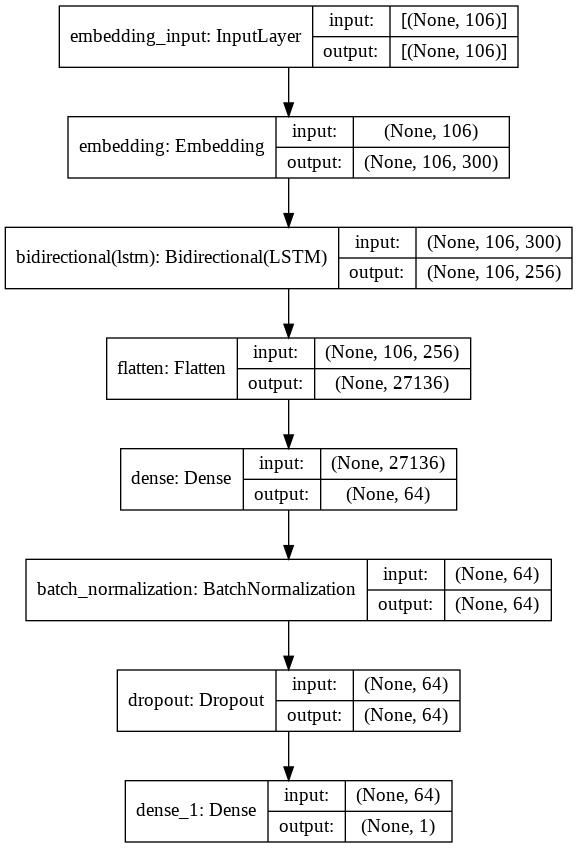

In [ ]:
#visualize the model and its parameters
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
#Build Model
batch_size = 100
epochs = 32

model_checkpoint = ModelCheckpoint('sarcasm.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1, save_freq='epoch')

callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

history = model.fit(Xtrain, ytrain, batch_size=batch_size, epochs=epochs, validation_data=(Xtest, ytest))


Epoch 1/32
443/443 [==============================] - 454s 1s/step - loss: 0.5171 - accuracy: 0.7467 - val_loss: 0.4930 - val_accuracy: 0.7925
Epoch 2/32
443/443 [==============================] - 451s 1s/step - loss: 0.3858 - accuracy: 0.8263 - val_loss: 0.3485 - val_accuracy: 0.8447
Epoch 3/32
443/443 [==============================] - 451s 1s/step - loss: 0.2824 - accuracy: 0.8808 - val_loss: 0.2770 - val_accuracy: 0.8843
Epoch 4/32
443/443 [==============================] - 450s 1s/step - loss: 0.1884 - accuracy: 0.9277 - val_loss: 0.2430 - val_accuracy: 0.9064
Epoch 5/32
443/443 [==============================] - 447s 1s/step - loss: 0.1230 - accuracy: 0.9558 - val_loss: 0.2162 - val_accuracy: 0.9225
Epoch 6/32
443/443 [==============================] - 449s 1s/step - loss: 0.0812 - accuracy: 0.9722 - val_loss: 0.2263 - val_accuracy: 0.9269
Epoch 7/32
443/443 [==============================] - 449s 1s/step - loss: 0.0564 - accuracy: 0.9812 - val_loss: 0.2103 - val_accuracy: 0.9411

In [ ]:
print("Testing Accuracy of the model: " , model.evaluate(Xtest,ytest))

346/346 [==============================] - 37s 106ms/step - loss: 0.4758 - accuracy: 0.9406
Testing Accuracy of the model:  [0.475824773311615, 0.9406289458274841]


In [ ]:
print("Training Accuracy of the model: " , model.evaluate(Xtrain,ytrain))

1384/1384 [==============================] - 147s 106ms/step - loss: 0.0251 - accuracy: 0.9909
Training Accuracy of the model:  [0.025117764249444008, 0.9908721446990967]


In [ ]:
ypred = model.predict(Xtest)
ypred[0]

array([1.], dtype=float32)

In [ ]:
ypred.shape

(11066, 1)

In [ ]:
l = len(ypred)

for i in range(l):
  if ypred[i] < .5 or ypred[i] ==.5:
    ypred[i] = str(0)
  else:
    ypred[i] = str(1)

In [ ]:
ypred[:10]

array([[1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.]], dtype=float32)

In [ ]:
print(classification_report(ytest, ypred, target_names = ['Non Sarcastic','Sarcastic']))

               precision    recall  f1-score   support

Non Sarcastic       0.92      0.98      0.95      5922
    Sarcastic       0.97      0.90      0.93      5144

     accuracy                           0.94     11066
    macro avg       0.94      0.94      0.94     11066
 weighted avg       0.94      0.94      0.94     11066



In [ ]:
cm = confusion_matrix(ytest,ypred)
cm

array([[5790,  132],
       [ 525, 4619]])

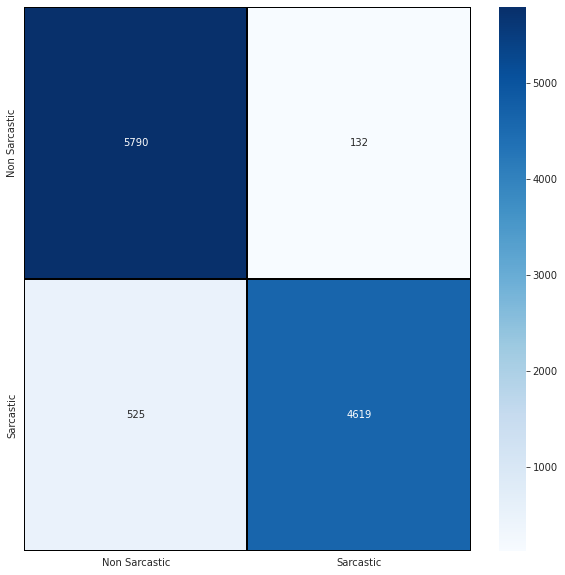

In [ ]:
cm = pd.DataFrame(cm , index = ['Non Sarcastic','Sarcastic'] , columns = ['Non Sarcastic','Sarcastic'])
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = ['Non Sarcastic','Sarcastic'] , yticklabels = ['Non Sarcastic','Sarcastic'])

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


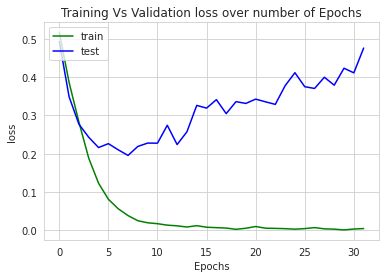

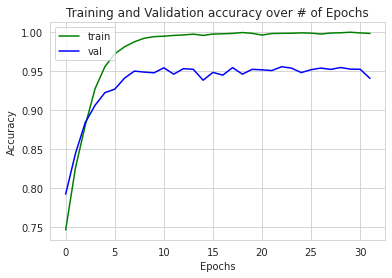

In [ ]:
# list all data in history
print(history.history.keys())

# summarize history for loss
plt.plot(history.history['loss'],'g', label='Training loss' )
plt.plot(history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(history.history['accuracy'], 'g', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

**Sarcasm Detection using BERT Model**

In [30]:
#Get BertTokenizer
berttokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/466k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [31]:
X=df['headline']
y=df['is_sarcastic']

In [32]:
tokenized_texts = [berttokenizer.tokenize(sent) for sent in X]

In [ ]:
X[0]

0    former versace store clerk sues secret black code minority shoppers
0             thirtysomething scientists unveil doomsday clock hair loss
Name: headline, dtype: object

In [33]:
tokenized_texts[0]

['former',
 'versa',
 '##ce',
 'store',
 'clerk',
 'sue',
 '##s',
 'secret',
 'black',
 'code',
 'minority',
 'shop',
 '##pers']

In [34]:
#We will use only first 200 tokens to do classification (this value can be changed)
max_length = 200
tokenized_texts = [sent[:max_length] for sent in tokenized_texts]

In [35]:
for i in range(len(tokenized_texts)):
    sent = tokenized_texts[i]
    sent = ['[CLS]'] + sent + ['[SEP]']
    tokenized_texts[i] = sent

In [ ]:
print(tokenized_texts[0])

['[CLS]', 'former', 'versa', '##ce', 'store', 'clerk', 'sue', '##s', 'secret', 'black', 'code', 'minority', 'shop', '##pers', '[SEP]']


In [36]:
#Convert tokens into IDs
input_ids = [berttokenizer.convert_tokens_to_ids(sent) for sent in tokenized_texts]

In [ ]:
print(input_ids[0])

[101, 2280, 18601, 3401, 3573, 7805, 9790, 2015, 3595, 2304, 3642, 7162, 4497, 7347, 102]


In [37]:
#Pad our tokens which might be less than max_length size
input_ids = tf.keras.preprocessing.sequence.pad_sequences(input_ids, maxlen=max_length+2, truncating='post', padding='post')

In [38]:
#80% data will be used for training while 20% will be used for test
trainX, testX, trainY, testY = train_test_split(input_ids, y, test_size=0.2, random_state=42)
trainX.shape, trainY.shape, testX.shape, testY.shape

((44260, 202), (44260,), (11066, 202), (11066,))

In [39]:
# Create attention masks for training
train_attn_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in trainX:
  seq_mask = [float(i>0) for i in seq]
  train_attn_masks.append(seq_mask)

In [40]:
# Create attention masks for Test
test_attn_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in testX:
  seq_mask = [float(i>0) for i in seq]
  test_attn_masks.append(seq_mask)

In [41]:
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased')

Downloading:   0%|          | 0.00/536M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
# Prepare training: Compile tf.keras model with optimizer, loss and learning rate schedule 
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5, epsilon=1e-08, clipnorm=1.0)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

In [43]:
model.summary()

Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bert (TFBertMainLayer)       multiple                  109482240 
_________________________________________________________________
dropout_37 (Dropout)         multiple                  0         
_________________________________________________________________
classifier (Dense)           multiple                  1538      
Total params: 109,483,778
Trainable params: 109,483,778
Non-trainable params: 0
_________________________________________________________________


In [44]:
train_x_data = {'input_ids': np.array(trainX), 'attention_mask': np.array(train_attn_masks)}
test_x_data = {'input_ids': np.array(testX), 'attention_mask': np.array(test_attn_masks)}

In [46]:
bert_history=model.fit(train_x_data, trainY, validation_data=(test_x_data, testY), batch_size=16, epochs=2)

Epoch 1/2
2767/2767 [==============================] - 3937s 1s/step - loss: 0.3053 - accuracy: 0.8683 - val_loss: 0.1600 - val_accuracy: 0.9407
Epoch 2/2
2767/2767 [==============================] - 3913s 1s/step - loss: 0.0803 - accuracy: 0.9722 - val_loss: 0.1225 - val_accuracy: 0.9608


In [47]:
model.evaluate(test_x_data, testY)

346/346 [==============================] - 293s 845ms/step - loss: 0.1225 - accuracy: 0.9608


[0.12250979244709015, 0.9607807993888855]

In [48]:
model.evaluate(train_x_data, trainY)

1384/1384 [==============================] - 1168s 844ms/step - loss: 0.0204 - accuracy: 0.9943


[0.020430978387594223, 0.9943289756774902]

In [49]:
ypred = model.predict(testX)
ypred[0]

array([[-3.3186476,  3.1911356],
       [-3.312154 ,  3.1826293],
       [-3.3912497,  3.265081 ],
       ...,
       [-3.452555 ,  3.3367054],
       [-3.540639 ,  3.4292538],
       [-3.65381  ,  3.543927 ]], dtype=float32)

**Observation: The Bert model gives better accuracy than LSTM, but it takes lot of time to train model and predict values.**

**The below piece of code are commented as the GPU ran out of memory space. The code was executed once and while try to tune, it failed due to space issue.**

In [3]:
# target_names = ['Sarcastic','Non Sarcastic']
# print(classification_report(testY, ypred[1],target_names=target_names))

In [ ]:
cm = confusion_matrix(testY,ypred)

cm = pd.DataFrame(cm , index = ['Non Sarcastic','Sarcastic'] , columns = ['Non Sarcastic','Sarcastic'])
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Red", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = ['Non Sarcastic','Sarcastic'] , yticklabels = ['Non Sarcastic','Sarcastic'])

In [ ]:
# list all data in history
print(bert_history.history.keys())

# summarize history for loss
plt.plot(bert_history.history['loss'],'g', label='Training loss' )
plt.plot(bert_history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(bert_history.history['accuracy'], 'g', label='Training accuracy')
plt.plot(bert_history.history['val_accuracy'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

**Conclusion:** By Analysing the LSTM model and the BERT Model, the transformer model works better than LSTM. Building a Bert Model can consume GPU space, but it is worth getting better accuracy and predictions.

**DISTILBERT MODEL:**

In [ ]:
# First load the real tokenizer
distilberttokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased' , lower = True)
# Save the loaded tokenizer locally
distilberttokenizer.save_pretrained('.')

('./tokenizer_config.json',
 './special_tokens_map.json',
 './vocab.txt',
 './added_tokens.json',
 './tokenizer.json')

In [ ]:
trainset= pd.read_json("/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/Assessment/Sarcasm_Headlines_Dataset.json", lines=True)
testset= pd.read_json("/content/drive/MyDrive/Colab Notebooks/R9-Sequence Model NLP/Assessment/Sarcasm_Headlines_Dataset_v2.json", lines=True)

In [ ]:
trainset.drop(['article_link'], axis=1, inplace=True)
testset.drop(['article_link'], axis=1, inplace=True)

In [ ]:
trainset.shape, testset.shape

((26709, 2), (28619, 2))

In [ ]:
trainset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26709 entries, 0 to 26708
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      26709 non-null  object
 1   is_sarcastic  26709 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 417.5+ KB


In [ ]:
trainset['headline'] = trainset['headline'].apply(preprocess_data)
testset['headline'] = testset['headline'].apply(preprocess_data)

In [ ]:
X_train=list(trainset['headline'])
X_train[:5]

['former versace store clerk sues secret black code minority shoppers',
 'roseanne revival catches thorny political mood better worse',
 'mom starting fear sons web series closest thing grandchild',
 'boehner wants wife listen come alternative debt-reduction ideas',
 'jk rowling wishes snape happy birthday magical way']

In [ ]:
X_test=list(testset['headline'])
X_test[:5]

['thirtysomething scientists unveil doomsday clock hair loss',
 'dem rep totally nails congress falling short gender racial equality',
 'eat veggies 9 deliciously different recipes',
 'inclement weather prevents liar getting work',
 'mother comes pretty close using word streaming correctly']

In [ ]:
y_train=list(trainset['is_sarcastic'])
y_train[:5]

[0, 0, 1, 1, 0]

In [ ]:
y_test=list(testset['is_sarcastic'])
y_test[:5]

[1, 0, 0, 1, 1]

In [ ]:
round(trainset['is_sarcastic'].value_counts()*100/len(trainset),2)

0   56.1000000
1   43.9000000
Name: is_sarcastic, dtype: float64

In [ ]:
round(testset['is_sarcastic'].value_counts()*100/len(testset),2)

0   52.3600000
1   47.6400000
Name: is_sarcastic, dtype: float64

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_encodings = distilberttokenizer(X_train, truncation=True, padding=True)
test_encodings = distilberttokenizer(X_test, truncation=True, padding=True)

In [ ]:
train_encodings[0]

Encoding(num_tokens=41, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
))

In [ ]:
train_dataset, test_dataset

(<TensorSliceDataset shapes: ({input_ids: (41,), attention_mask: (41,)}, ()), types: ({input_ids: tf.int32, attention_mask: tf.int32}, tf.int32)>,
 <TensorSliceDataset shapes: ({input_ids: (133,), attention_mask: (133,)}, ()), types: ({input_ids: tf.int32, attention_mask: tf.int32}, tf.int32)>)

In [ ]:
 #If config.num_labels == 1 a regression loss is computed (Mean-Square loss), If config.num_labels > 1 a classification loss is computed (Cross-Entropy).
distilBERT_model = TFDistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_transform', 'vocab_layer_norm', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'dropout_59', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
distilBERT_model.compile(optimizer=optimizer, loss=distilBERT_model.compute_loss, metrics=['accuracy'])

In [ ]:
distilBERT_model.summary()

Model: "tf_distil_bert_for_sequence_classification_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
distilbert (TFDistilBertMain multiple                  66362880  
_________________________________________________________________
pre_classifier (Dense)       multiple                  590592    
_________________________________________________________________
classifier (Dense)           multiple                  1538      
_________________________________________________________________
dropout_59 (Dropout)         multiple                  0         
Total params: 66,955,010
Trainable params: 66,955,010
Non-trainable params: 0
_________________________________________________________________


In [ ]:
distilBERT_model.fit(train_dataset.shuffle(42).batch(16),epochs=2,batch_size=16,validation_data=test_dataset.shuffle(42).batch(16))

Epoch 1/2
1670/1670 [==============================] - 584s 344ms/step - loss: 0.3874 - accuracy: 0.8249 - val_loss: 0.2095 - val_accuracy: 0.9372
Epoch 2/2
1670/1670 [==============================] - 576s 345ms/step - loss: 0.1647 - accuracy: 0.9357 - val_loss: 0.1128 - val_accuracy: 0.9593


**The below piece of code are commented as the GPU ran out of memory space. The code was executed once and while try to tune, it failed due to space issue.**

In [ ]:
#distilBERT_model.evaluate(test_dataset)

In [ ]:
#ypred=distilBERT_model.predict(test_dataset)

In [ ]:
ypred[:5]

(array([[0.02036034],
        [0.04112867],
        [0.95241195],
        ...,
        [0.7753199 ],
        [0.7753199 ],
        [0.7753199 ]], dtype=float32),)

In [ ]:
#ypred=ypred.round().astype(int)

In [ ]:
ypred[:5]

(array([[0.02036034],
        [0.04112867],
        [0.95241195],
        ...,
        [0.7753199 ],
        [0.7753199 ],
        [0.7753199 ]], dtype=float32),)

In [ ]:
# target_names = ['Sarcastic','Non Sarcastic']
# print(classification_report(y_test,
#                             ypred[1],target_names=target_names
#                            )
#      )

In [ ]:
cm = confusion_matrix(y_test,pred)
cm

In [ ]:
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='')
plt.xlabel("Predicted")
plt.ylabel("Actual")